In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ziyadaltalhi/tik-tok-data/Tik Tok Datasets - After Processing/المنطقة الوسطى/Tik Data/القصيم/dataset_tiktok-comments-scraper_2025-11-05_23-34-09-183_textready_analysis.xlsx
/kaggle/input/datasets/ziyadaltalhi/tik-tok-data/Tik Tok Datasets - After Processing/المنطقة الوسطى/Tik Data/القصيم/dataset_tiktok-comments-scraper_2025-11-05_23-06-43-625_textready_analysis.xlsx
/kaggle/input/datasets/ziyadaltalhi/tik-tok-data/Tik Tok Datasets - After Processing/المنطقة الوسطى/Tik Data/القصيم/dataset_tiktok-comments-scraper_2025-11-05_23-17-06-320_textready_cleaned.xlsx
/kaggle/input/datasets/ziyadaltalhi/tik-tok-data/Tik Tok Datasets - After Processing/المنطقة الوسطى/Tik Data/القصيم/dataset_tiktok-comments-scraper_2025-11-05_23-37-52-643_textready_analysis.xlsx
/kaggle/input/datasets/ziyadaltalhi/tik-tok-data/Tik Tok Datasets - After Processing/المنطقة الوسطى/Tik Data/القصيم/dataset_tiktok-comments-scraper_2025-11-05_23-36-16-596_textready_analysis.xlsx
/kaggle/input/dataset

In [16]:
PATHS = [
    "/kaggle/input/datasets/aymanalzahrani7/graduation-projectd/Graduation Project/Cleaned Data From Google Maps/",
    "/kaggle/input/datasets/ziyadaltalhi/youtube-data/YouTube Datasets - After Processing/",
    "/kaggle/input/datasets/ziyadaltalhi/tik-tok-data/Tik Tok Datasets - After Processing/"
]

In [17]:
import os
import glob
import pandas as pd

TEXT_COL = "Text_TR"
FILTER_SOURCES = ["tik-tok", "youtube"]
# =========================================
# قراءة أي ملف
# =========================================
def read_any_file(path):
    ext = os.path.splitext(path)[1].lower()

    if ext in [".xlsx", ".xls"]:
        df = pd.read_excel(path)

    elif ext == ".csv":
        try:
            df = pd.read_csv(path, encoding="utf-8")
        except:
            try:
                df = pd.read_csv(path, encoding="utf-8-sig")
            except:
                df = pd.read_csv(path, encoding="cp1256")
    else:
        return None

    df.columns = [str(c).strip() for c in df.columns]
    return df


# =========================================
# توحيد عمود النجوم
# =========================================
def standardize_star_column(df):
    for col in df.columns:
        if col.lower() == "stars":
            df = df.rename(columns={col: "Stars"})
            break
    return df


# =========================================
# جلب الملفات مع الفلترة الذكية
# =========================================
def get_all_files(root):
    files = []

    for r, d, f in os.walk(root):
        for file in f:
            name = file.lower()
            full_path = os.path.join(r, file)

            # امتدادات فقط
            if not name.endswith((".csv", ".xlsx", ".xls")):
                continue

            path_lower = full_path.lower()

            # هل المصدر TikTok أو YouTube؟
            is_filtered_source = any(src in path_lower for src in FILTER_SOURCES)

            # طبق الفلترة فقط عليهم
            if is_filtered_source:
                if "analysis" not in name or "summary" in name:
                    continue

            files.append(full_path)

    return files


# =========================================
# تحميل البيانات النهائية
# =========================================
def load_simple(paths):
    all_data = []

    for root in paths:
        print(f"\n📂 Reading from: {root}")

        files = get_all_files(root)
        print("Total files after filter:", len(files))

        for i, f in enumerate(files, 1):
            try:
                df = read_any_file(f)
                if df is None:
                    continue

                df = standardize_star_column(df)

                # تحقق من الأعمدة المطلوبة
                if TEXT_COL not in df.columns or "Stars" not in df.columns:
                    continue

                df = df[[TEXT_COL, "Stars"]].copy()
                all_data.append(df)

                if i % 50 == 0:
                    print(f"Progress: {i}/{len(files)}")

            except Exception as e:
                print(f"❌ Error reading: {f}")

    df1 = pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

    # تنظيف بسيط
    if not df1.empty:
        df1 = df1.dropna(subset=[TEXT_COL, "Stars"])
        df1[TEXT_COL] = df1[TEXT_COL].astype(str)

    return df1

In [18]:
# =========================================
# تشغيل
# =========================================
df1 = load_simple(PATHS)

print("\n✅ Final Shape:", df1.shape)
print(df1.head())


📂 Reading from: /kaggle/input/datasets/aymanalzahrani7/graduation-projectd/Graduation Project/Cleaned Data From Google Maps/
Total files after filter: 442
Progress: 50/442
Progress: 100/442
Progress: 150/442
Progress: 200/442
Progress: 250/442
Progress: 300/442
Progress: 350/442
Progress: 400/442

📂 Reading from: /kaggle/input/datasets/ziyadaltalhi/youtube-data/YouTube Datasets - After Processing/
Total files after filter: 198
Progress: 50/198
Progress: 100/198
Progress: 150/198

📂 Reading from: /kaggle/input/datasets/ziyadaltalhi/tik-tok-data/Tik Tok Datasets - After Processing/
Total files after filter: 296
Progress: 50/296
Progress: 100/296
Progress: 150/296
Progress: 200/296
Progress: 250/296


/tmp/ipykernel_55/2003601722.py:105: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df1 = pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()



✅ Final Shape: (537977, 2)
                                              Text_TR  Stars
1   رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...    3.0
5   المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...    4.0
7                                           ممتاز جدا    5.0
9                                          منتزه مميز    5.0
12                                     منتزه جميل جدا    5.0


In [19]:
df1

,Text_TR,Stars
1,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,3.0
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,4.0
7,ممتاز جدا,5.0
9,منتزه مميز,5.0
12,منتزه جميل جدا,5.0
...,...,...
1043213,البحر عندنا في مكه ومسكون كله جن الافضل تروح ا...,5.0
1043214,كثير نروح له جميل و هو بحر مجرمة من اجمل الذكريات,5.0
1043215,حوليه السفينه فيها اشياء غريبه ومخيفة امام اعي...,1.0
1043216,صحيح من حارتنا مات ثلاثة هناك,1.0


In [20]:
# =========================================================
# (2) FILTER ONLY TRULY-EMPTY Text_TR (NaN + "" + "nan" + "[]" ...)
# =========================================================
print(f"\n[STEP 2] Using {TEXT_COL} + strong empty filter")

# ✅ الداتا الجديدة
if TEXT_COL not in df1.columns:
    raise ValueError(f"عمود {TEXT_COL} غير موجود في البيانات.")

before2 = len(df1)

# لا نحول إلى string الآن (مهم)
s = df1[TEXT_COL]

empty_like = {
    "", "nan", "NaN", "none", "None", "NONE",
    "<NA>", "[]", "[ ]", "{}", "null", "NULL"
}

empty_mask = (
    s.isna() |
    s.astype(str).str.strip().isin(empty_like)
)

empty_count = int(empty_mask.sum())

# ✅ الناتج الجديد
df2 = df1.loc[~empty_mask].copy()

# العمود الذي سيستخدم لاحقاً للمودل
df2["TEXT_FOR_MODEL"] = df2[TEXT_COL].astype(str).str.strip()

print("\n[STEP 2 RESULT]")
print("Rows before:", before2)
print("Empty-like rows:", empty_count)
print("Rows after:", len(df2))

print("\nSample empty-like values:")
print(s.loc[empty_mask].head(10).astype(str).tolist())


[STEP 2] Using Text_TR + strong empty filter

[STEP 2 RESULT]
Rows before: 537977
Empty-like rows: 0
Rows after: 537977

Sample empty-like values:
[]


In [23]:
# =========================================================
# (4) SAFE TEXT CLEANING (INDEPENDENT)
#   - لا يعتمد على Stars_num أو y_bin
#   - يحافظ على الأعمدة التعريفية
# =========================================================

import re
import pandas as pd

print("\n[STEP 4] Safe Cleaning (Independent)")

TEXT_COL = "Text_TR"

if TEXT_COL not in df2.columns:
    raise ValueError(f"{TEXT_COL} غير موجود في df2")

# =========================
# Regex definitions
# =========================
AR_DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670]")
AR_TATWEEL_RE    = re.compile(r"\u0640")

# =========================
# Safe Arabic normalization
# =========================
def normalize_arabic_safe(text: str) -> str:
    text = AR_DIACRITICS_RE.sub("", text)   # remove diacritics
    text = AR_TATWEEL_RE.sub("", text)      # remove tatweel (ـ)
    text = re.sub(r"[إأآا]", "ا", text)      # unify alef only
    return text

# =========================
# Main cleaning function
# =========================
def clean_text(s):
    if pd.isna(s):
        return ""
    
    s = str(s).strip().lower()
    if not s:
        return ""

    # remove links / emails / mentions / hashtags
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"\S+@\S+", " ", s)
    s = re.sub(r"@\w+", " ", s)
    s = re.sub(r"#\w+", " ", s)

    # remove emojis
    s = re.sub(r"[\U00010000-\U0010ffff]", " ", s)

    # keep Arabic / English / digits / spaces
    s = re.sub(r"[^0-9a-z\u0600-\u06FF\s]", " ", s)

    # safe normalize
    s = normalize_arabic_safe(s)

    # reduce repeated letters (جمييييل -> جمييل)
    s = re.sub(r"(.)\1{2,}", r"\1\1", s)

    # collapse spaces
    s = re.sub(r"\s+", " ", s).strip()

    # remove if numbers only
    if re.fullmatch(r"\d+", s):
        return ""

    return s


# =========================
# Preserve metadata columns if exist
# =========================
META_COLS = ["Stars"]
meta_existing = [c for c in META_COLS if c in df2.columns]

# =========================
# BEFORE dataframe
# =========================
df_before_clean = df2[[TEXT_COL] + meta_existing].copy()
df_before_clean = df_before_clean.rename(columns={TEXT_COL: "text_before"})

display(df_before_clean.head(10))


# =========================
# Apply cleaning
# =========================
df4 = df2.copy()
df4["text_clean"] = df4[TEXT_COL].apply(clean_text)

# =========================
# Compare dataframe
# =========================
df_compare = df4[[TEXT_COL, "text_clean"] + meta_existing].copy()
df_compare = df_compare.rename(columns={TEXT_COL: "text_before"})

display(df_compare.head(20))


# =========================
# Removed rows (empty after clean)
# =========================
df_removed = df_compare[df_compare["text_clean"].str.len() == 0].copy()

print("Removed rows (empty after clean):", len(df_removed))
display(df_removed.head(20))


# =========================
# Final cleaned dataframe
# =========================
df4 = df_compare[df_compare["text_clean"].str.len() > 0].copy()

print("Final cleaned shape:", df4.shape)
print("Columns:", df4.columns.tolist())

display(df4.head(20))


# =========================
# Safety check examples
# =========================
print("\n[CHECK] safe normalization examples:")
for t in ["سيئ", "سيئة", "سيء", "المكان سيئ جدا", "المكان رائع جدا", "12345", "مطعم 123"]:
    print(f"{t}  ->  {clean_text(t)}")


[STEP 4] Safe Cleaning (Independent)


,text_before,Stars
1,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,3.0
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,4.0
7,ممتاز جدا,5.0
9,منتزه مميز,5.0
12,منتزه جميل جدا,5.0
14,دخول الكرفان 80ريال لذا لم ادخل,2.0
15,ممتازة,5.0
17,الحذر ثم الحذر خطر الموت فاليوم الله انجانا من...,1.0
20,اقل شي ممكن تسوية مقابل الرسوم انك تتهتم بالنظ...,3.0
23,اكثر من رائع ونظيف جدايمتاز بالجلسات بين الاشج...,5.0


,text_before,text_clean,Stars
1,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,3.0
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,4.0
7,ممتاز جدا,ممتاز جدا,5.0
9,منتزه مميز,منتزه مميز,5.0
12,منتزه جميل جدا,منتزه جميل جدا,5.0
14,دخول الكرفان 80ريال لذا لم ادخل,دخول الكرفان 80ريال لذا لم ادخل,2.0
15,ممتازة,ممتازة,5.0
17,الحذر ثم الحذر خطر الموت فاليوم الله انجانا من...,الحذر ثم الحذر خطر الموت فاليوم الله انجانا من...,1.0
20,اقل شي ممكن تسوية مقابل الرسوم انك تتهتم بالنظ...,اقل شي ممكن تسوية مقابل الرسوم انك تتهتم بالنظ...,3.0
23,اكثر من رائع ونظيف جدايمتاز بالجلسات بين الاشج...,اكثر من رائع ونظيف جدايمتاز بالجلسات بين الاشج...,5.0


Removed rows (empty after clean): 2641


,text_before,text_clean,Stars
74771,5,,5.0
82957,١٠٠,,5.0
83371,٦٦,,4.0
101483,٩,,1.0
106298,1961,,1.0
106314,2024,,5.0
106366,2023,,5.0
106383,100,,5.0
106390,1361,,5.0
106446,1361,,5.0


Final cleaned shape: (535336, 3)
Columns: ['text_before', 'text_clean', 'Stars']


,text_before,text_clean,Stars
1,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,3.0
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,4.0
7,ممتاز جدا,ممتاز جدا,5.0
9,منتزه مميز,منتزه مميز,5.0
12,منتزه جميل جدا,منتزه جميل جدا,5.0
14,دخول الكرفان 80ريال لذا لم ادخل,دخول الكرفان 80ريال لذا لم ادخل,2.0
15,ممتازة,ممتازة,5.0
17,الحذر ثم الحذر خطر الموت فاليوم الله انجانا من...,الحذر ثم الحذر خطر الموت فاليوم الله انجانا من...,1.0
20,اقل شي ممكن تسوية مقابل الرسوم انك تتهتم بالنظ...,اقل شي ممكن تسوية مقابل الرسوم انك تتهتم بالنظ...,3.0
23,اكثر من رائع ونظيف جدايمتاز بالجلسات بين الاشج...,اكثر من رائع ونظيف جدايمتاز بالجلسات بين الاشج...,5.0



[CHECK] safe normalization examples:
سيئ  ->  سيئ
سيئة  ->  سيئة
سيء  ->  سيء
المكان سيئ جدا  ->  المكان سيئ جدا
المكان رائع جدا  ->  المكان رائع جدا
12345  ->  
مطعم 123  ->  مطعم 123


In [34]:
df4

,text_before,text_clean,Stars,label
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,4.0,1
7,ممتاز جدا,ممتاز جدا,5.0,1
9,منتزه مميز,منتزه مميز,5.0,1
12,منتزه جميل جدا,منتزه جميل جدا,5.0,1
14,دخول الكرفان 80ريال لذا لم ادخل,دخول الكرفان 80ريال لذا لم ادخل,2.0,0
...,...,...,...,...
1043213,البحر عندنا في مكه ومسكون كله جن الافضل تروح ا...,البحر عندنا في مكه ومسكون كله جن الافضل تروح ا...,5.0,1
1043214,كثير نروح له جميل و هو بحر مجرمة من اجمل الذكريات,كثير نروح له جميل و هو بحر مجرمة من اجمل الذكريات,5.0,1
1043215,حوليه السفينه فيها اشياء غريبه ومخيفة امام اعي...,حوليه السفينه فيها اشياء غريبه ومخيفة امام اعي...,1.0,0
1043216,صحيح من حارتنا مات ثلاثة هناك,صحيح من حارتنا مات ثلاثة هناك,1.0,0


In [35]:
df4['Stars'].value_counts()

Stars
5.0    319881
4.0     86914
1.0     48823
2.0     20502
Name: count, dtype: int64

In [26]:
df4 = df4[df4["Stars"] != 3]

In [27]:
def convert_stars(star):
    if star >= 4:
        return 1  # إيجابي
    else:
        return 0  # سلبي

df4["label"] = df4["Stars"].apply(convert_stars)

/tmp/ipykernel_55/726487382.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4["label"] = df4["Stars"].apply(convert_stars)


In [28]:
print(df4["label"].value_counts())

label
1    406795
0     69325
Name: count, dtype: int64


In [32]:
df5 = df4[["text_clean", "label"]].dropna()

In [33]:
df5

,text_clean,label
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,1
7,ممتاز جدا,1
9,منتزه مميز,1
12,منتزه جميل جدا,1
14,دخول الكرفان 80ريال لذا لم ادخل,0
...,...,...
1043213,البحر عندنا في مكه ومسكون كله جن الافضل تروح ا...,1
1043214,كثير نروح له جميل و هو بحر مجرمة من اجمل الذكريات,1
1043215,حوليه السفينه فيها اشياء غريبه ومخيفة امام اعي...,0
1043216,صحيح من حارتنا مات ثلاثة هناك,0


In [46]:
from datasets import Dataset

dataset = Dataset.from_pandas(df5)
dataset = dataset.train_test_split(test_size=0.2)

In [47]:
from imblearn.over_sampling import RandomOverSampler

# 2) تحويل train إلى pandas
train_df = dataset["train"].to_pandas()

# 3) فصل X و y (فقط على train)
X = train_df[["text_clean"]]
y = train_df["label"]

# 4) تطبيق oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# 5) إعادة الدمج
train_balanced = pd.concat([X_resampled, y_resampled], axis=1)

# 6) خلط البيانات
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 7) إرجاعه إلى Dataset
dataset["train"] = Dataset.from_pandas(train_balanced)

In [48]:
print(dataset["train"].to_pandas()["label"].value_counts())
print(dataset["test"].to_pandas()["label"].value_counts())

label
1    325434
0    325434
Name: count, dtype: int64
label
1    81361
0    13863
Name: count, dtype: int64


In [49]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# تعريف اللابلز (مهم)
model.config.id2label = {0: "Negative", 1: "Positive"}
model.config.label2id = {"Negative": 0, "Positive": 1}

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment
Key                          | Status     |                                                                                     
-----------------------------+------------+-------------------------------------------------------------------------------------
bert.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.weight            | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.bias              | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [50]:
def tokenize(batch):
    return tokenizer(batch["text_clean"], truncation=True, padding="max_length", max_length=128)

dataset = Dataset.from_pandas(df5).train_test_split(test_size=0.2)
dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/380896 [00:00<?, ? examples/s]

Map:   0%|          | 0/95224 [00:00<?, ? examples/s]

In [51]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./camel_binary",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=4,
    logging_dir="./logs",
    save_steps=0   # مهم لتجنب الخطأ عندك
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [52]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"]
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
500,0.411015
1000,0.393123
1500,0.365806
2000,0.362030
2500,0.357362
3000,0.374766
3500,0.353670
4000,0.353862
4500,0.342757
5000,0.358008


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=47612, training_loss=0.2668628476301602, metrics={'train_runtime': 21275.8327, 'train_samples_per_second': 71.611, 'train_steps_per_second': 2.238, 'total_flos': 1.0021794854240256e+17, 'train_loss': 0.2668628476301602, 'epoch': 4.0})

In [53]:
pred_output = trainer.predict(dataset["test"])

y_true = pred_output.label_ids
y_pred = pred_output.predictions.argmax(axis=1)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [54]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 Macro:", f1_score(y_true, y_pred, average="macro"))
print("Precision Macro:", precision_score(y_true, y_pred, average="macro"))
print("Recall Macro:", recall_score(y_true, y_pred, average="macro"))

Accuracy: 0.9414223305049148
F1 Macro: 0.8787311853870376
Precision Macro: 0.890434930905273
Recall Macro: 0.8680459586145288


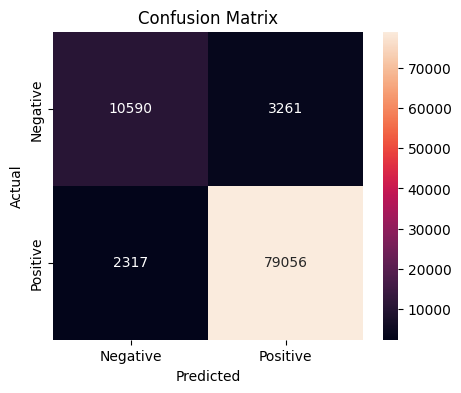

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [56]:
from sklearn.metrics import classification_report

pred_output = trainer.predict(dataset["test"])

y_true = pred_output.label_ids
y_pred = pred_output.predictions.argmax(axis=1)

report = classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    digits=2
)

print(report)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

    Negative       0.82      0.76      0.79     13851
    Positive       0.96      0.97      0.97     81373

    accuracy                           0.94     95224
   macro avg       0.89      0.87      0.88     95224
weighted avg       0.94      0.94      0.94     95224



In [58]:
model.save_pretrained("./camelbert_final")
tokenizer.save_pretrained("./camelbert_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./camelbert_final/tokenizer_config.json', './camelbert_final/tokenizer.json')